<a id='importar-librerias'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
Importar Librerías

In [2]:
# para manipulación y análisis de datos estructurados
import pandas as pd

# es el módulo principal de matplotlib, 
# una librería de visualización de gráficos estáticos en 2D.
import matplotlib.pyplot as plt

# Es una magic command de Jupyter Notebook
%matplotlib inline

# es una librería de visualización construida sobre matplotlib, 
# con una sintaxis más simple y gráficos más bonitos
import seaborn as sns

In [1]:
#!pip install pyarrow

In [ ]:
# Identifique el método utilizado para capturar los datos, por ejemplo, ODBC.
transactions = pd.read_parquet('../transactions_agg.parquet') # --> Transactions_agg(dataset sin duplicados)

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">se multiplica por 50000 dado que los datos son anonimizados

In [6]:
transactions.price = transactions.price*50000

In [7]:
pd.set_option('display.float_format', '{:.6f}'.format) 
transactions.describe()

,article_id,sales_channel_id,price
count,28583889.000000,28583889.000000,28583889.000000
mean,697398489.243995,1.682593,1547.455586
std,131727610.245217,0.465467,1278.020702
min,108775015.000000,1.000000,0.847458
25%,633377003.000000,1.000000,846.610169
50%,714790003.000000,2.000000,1270.338983
75%,787216001.000000,2.000000,1755.084746
max,956217002.000000,2.000000,283322.033898


In [8]:
transactions.head()

,t_dat,customer_id,article_id,sales_channel_id,price
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,2,1524.576271
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,2,2541.525424
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221001,2,1016.101695
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,2,761.864407
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687001,2,846.610169


<a id='knn'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
Modelo LRFM

In [9]:
import dask.dataframe as dd

In [10]:
# filtrar columnas
dd_knn = dd.from_pandas(transactions[["customer_id", "price", "t_dat"]], npartitions=2)

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Frecuencia


In [11]:
# Agrupar por cliente y contar transacciones
frecuency = (
    dd_knn
    .groupby("customer_id")
    .agg(Frequency=("customer_id", "count"))
    .reset_index()
)

# Si quieres materializar el resultado en pandas
frecuency_result = frecuency.compute()

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Cantidad

In [12]:
# Agrupar por cliente y sumar la columna price
amount = (
    dd_knn
    .groupby("customer_id")
    .agg(Sold=("price", "sum"))
    .reset_index()
)

# Si quieres traerlo a pandas
amount_result = amount.compute()

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
RECENCIA

In [13]:
# Asegurar fecha
dd_knn["t_dat"] = dd.to_datetime(dd_knn["t_dat"])

def calculate_purchase_intervals(df):
    """
    Función para aplicar por partición que replica la lógica SQL
    """
    # Ordenar por customer_id y fecha
    df = df.sort_values(['customer_id', 't_dat'])
    
    # Crear la columna prev usando shift agrupado por customer_id
    df['prev'] = df.groupby('customer_id')['t_dat'].shift(1)
    
    # Crear ranking descendente por fecha (más reciente = 1)
    df['rnum'] = df.groupby('customer_id')['t_dat'].rank(method='dense', ascending=False)
    
    # Filtrar solo las compras más recientes con compra previa
    result = df[(df['rnum'] == 1) & (df['prev'].notna())].copy()
    
    # Calcular diferencia en días
    if not result.empty:
        result['Days'] = (result['t_dat'] - result['prev']).dt.days
        result = result[['customer_id', 't_dat', 'prev', 'Days']]
    
    return result

In [14]:
# Aplicar la función usando map_partitions
lastbuy_result = dd_knn.map_partitions(
    calculate_purchase_intervals,
    meta=pd.DataFrame({
        'customer_id': pd.Series(dtype='object'),
        't_dat': pd.Series(dtype='datetime64[ns]'),
        'prev': pd.Series(dtype='datetime64[ns]'),
        'Days': pd.Series(dtype='int64')
    })
).compute()

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Length

In [15]:
# Asegurar que 't_dat' esté en formato fecha
dd_knn["t_dat"] = dd.to_datetime(dd_knn["t_dat"])

In [16]:
# Agrupar por cliente y calcular la fecha mínima y máxima
duration_metrics = dd_knn.groupby('customer_id').agg(
    first_purchase=('t_dat', 'min'),
    last_purchase=('t_dat', 'max')
).reset_index()

In [17]:
# Calcular la duración (Length) en días
# Dask permite operaciones de tiempo vectorizadas en sus DataFrames
duration_metrics['Length_raw'] = (duration_metrics['last_purchase'] - duration_metrics['first_purchase']).dt.days

In [ ]:
# Manejo del caso de clientes con una sola compra (Duration = 0).
# Usamos map para aplicar una función que garantiza que el Length sea al menos 1 día.
def ensure_min_length(df):
    """Asegura que la duración sea al menos 1 día si el cliente hizo una sola compra."""
    df['Length'] = df['Length_raw'].apply(lambda x: x if x >= 1 else 1)
    return df[['customer_id', 'Length']]

# Aplicar la función a las particiones
length = duration_metrics.map_partitions(
    ensure_min_length,
    meta=pd.DataFrame({
        'customer_id': pd.Series(dtype='object'),
        'Length': pd.Series(dtype='int64')
    })
)

# Si quieres materializar el resultado en pandas
length_result = length.compute()

# Mostrar el resultado
print(" Cálculo de Length completado.")
print(length_result.head())

 Cálculo de Length completado.
                                         customer_id  Length
0  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...     726
1  00007d2de826758b65a93dd24ce629ed66842531df6699...     601
2  00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4...     559
3  0008968c0d451dbc5a9968da03196fe20051965edde741...     725
4  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...     573


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Consolidado

In [19]:
# 1. Unir Frecuencia y Cantidad (Monetario/Sold)
retail = frecuency.merge(amount, on="customer_id", how="inner")

# Unir con recency
retail = retail.merge(lastbuy_result[["customer_id", "Days"]], on="customer_id", how="inner")

#Unir con Length
retail = retail.merge(length_result[["customer_id","Length"]], on="customer_id",how="inner")

# Si quieres ver el resultado
retail_result = retail.compute()

In [20]:
retail_result.head()

,customer_id,Frequency,Sold,Days,Length
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,158,726
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,150,726
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,152,601
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601


In [ ]:
# Guardar resultado
retail_result.to_parquet("./lakehouse/lrfm_retail_parquet", engine="pyarrow")

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">KNN

In [22]:
from sklearn.cluster import KMeans

In [23]:
# 1. Preparar las features (equivalente a VectorAssembler)
feature_columns = ["Frequency", "Sold", "Days","Length"]
X = retail_result[feature_columns].values

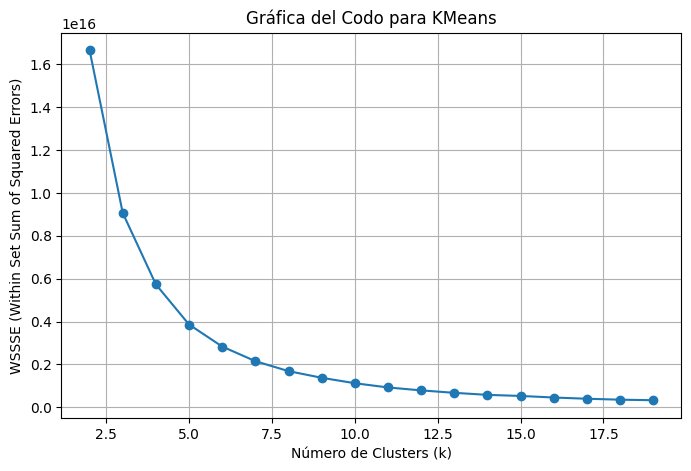

CPU times: total: 5min 45s
Wall time: 2min 11s


In [24]:
%%time

# 2. Método del codo para encontrar el mejor k
import matplotlib.pyplot as plt

cost = []
K = list(range(2, 20))

for k in K:
    kmeans = KMeans(k, random_state = 1)
    kmeans.fit(X)
    cost.append(kmeans.inertia_)  # WSSSE

# Graficar el codo
plt.figure(figsize=(8, 5))
plt.plot(K, cost, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WSSSE (Within Set Sum of Squared Errors)')
plt.title('Gráfica del Codo para KMeans')
plt.grid(True)
plt.show()

In [25]:
# 3. Aplicar KMeans con el mejor k
best_k = 6

kmeans_final = KMeans(n_clusters=best_k, random_state=1, n_init=10)
clusters = kmeans_final.fit_predict(X)  

In [26]:
# 4. Agregar predicciones al DataFrame
retail_result['prediction'] = clusters

In [27]:
retail_result[["customer_id", "prediction"]].head()

,customer_id,prediction
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,3
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,3
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,3


In [28]:
# 5. Análisis detallado por segmento Simple
cluster_analysis = retail_result.groupby("prediction")[feature_columns].mean()
cluster_analysis

,Frequency,Sold,Days,Length
prediction,,,,
0,13.666578,17820.423165,15.773536,272.282758
1,244.816290,470249.172922,3.434950,680.699603
2,45.888994,67491.988446,12.590030,542.816903
3,88.604702,144367.567945,8.006224,613.847448
4,444.113768,924741.673822,1.965605,697.485840
5,149.592816,264499.296260,5.326046,654.524937


In [29]:
# 6. Análisis detallado por segmento
detailed_analysis = retail_result.groupby("prediction").agg({
    'Length': ['mean', 'std', 'count'],
    'Frequency': ['mean', 'std', 'count'],
    'Sold': ['mean', 'std'],
    'Days': ['mean', 'std']
}).round(2)
detailed_analysis

Length                      Frequency                      \
                 mean        std    count       mean        std    count   
prediction                                                                 
0          272.280000 244.110000  3389799  13.670000   9.230000  3389799   
1          680.700000  61.300000    66948 244.820000  71.960000    66948   
2          542.820000 156.850000  1354329  45.890000  16.900000  1354329   
3          613.850000 110.400000   549530  88.600000  27.230000   549530   
4          697.490000  53.950000    10205 444.110000 144.050000    10205   
5          654.520000  79.810000   212292 149.590000  42.460000   212292   

                    Sold                    Days            
                    mean           std      mean       std  
prediction                                                  
0           17820.420000  11230.270000 15.770000 45.330000  
1          470249.170000  84468.070000  3.430000 12.690000  
2           67491.990000  17688.580000 12.590000 35.430000  
3          144367.570000  27402.950000  8.010000 25.320000  
4          924741.670000 254879.970000  1.970000  7.810000  
5          264499.300000  44857.390000  5.330000 18.370000

In [30]:
# 7. Guardar resultado
retail_result.to_parquet("./lakehouse/lrfm_retail_with_clusters.parquet", engine="pyarrow", index=False)

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">LRFM - SCORE

In [44]:
import re

In [45]:
feature_columns = ["customer_id", "Frequency", "Sold", "Days","Length"]
lrfm = retail_result[feature_columns]

In [46]:
# Calcular percentiles (Rank)
lrfm['recency_percentile'] = lrfm['Days'].rank(method='min') / len(lrfm)
lrfm['frequency_percentile'] = lrfm['Frequency'].rank(method='min') / len(lrfm)
lrfm['monetary_percentile'] = lrfm['Sold'].rank(method='min') / len(lrfm) 
lrfm['length_percentile'] = lrfm['Length'].rank(method='min') / len(lrfm) 

In [47]:
# Asignar scores LRFM usando condiciones
def assign_length_score(percentile):
    """Mayor length = mejor score"""
    if percentile <= 0.2:
        return 1
    elif percentile <= 0.4:
        return 2
    elif percentile <= 0.6:
        return 3
    elif percentile <= 0.8:
        return 4
    else:
        return 5


def assign_recency_score(percentile):
    """Menor Days = mejor score (más reciente)"""
    if percentile <= 0.2:
        return 5
    elif percentile <= 0.4:
        return 4
    elif percentile <= 0.6:
        return 3
    elif percentile <= 0.8:
        return 2
    else:
        return 1

def assign_frequency_score(percentile):
    """Mayor Frequency = mejor score"""
    if percentile <= 0.2:
        return 1
    elif percentile <= 0.4:
        return 2
    elif percentile <= 0.6:
        return 3
    elif percentile <= 0.8:
        return 4
    else:
        return 5

def assign_monetary_score(percentile):
    """Mayor monetary = mejor score"""
    if percentile <= 0.2:
        return 1
    elif percentile <= 0.4:
        return 2
    elif percentile <= 0.6:
        return 3
    elif percentile <= 0.8:
        return 4
    else:
        return 5

In [48]:
# Aplicar las funciones
lrfm['length_score'] = lrfm['length_percentile'].apply(assign_length_score)
lrfm['frequency_score'] = lrfm['frequency_percentile'].apply(assign_frequency_score)
lrfm['recency_score'] = lrfm['recency_percentile'].apply(assign_recency_score)
lrfm['monetary_score'] = lrfm['monetary_percentile'].apply(assign_monetary_score)


In [49]:
# 3. Crear LRFM_score concatenando recency y frequency
lrfm['LRFM_score'] = lrfm['recency_score'].astype(str) + lrfm['frequency_score'].astype(str)  +  lrfm['monetary_score'].astype(str) + lrfm['length_score'].astype(str) 

In [50]:
lrfm

,customer_id,Frequency,Sold,Days,Length,recency_percentile,frequency_percentile,monetary_percentile,length_percentile,length_score,frequency_score,recency_score,monetary_score,LRFM_score
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,158,726,0.976945,0.372715,0.547323,0.993015,5,2,1,3,1235
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,150,726,0.974532,0.372715,0.547323,0.993015,5,2,1,3,1235
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,152,601,0.975128,0.937550,0.941064,0.695211,4,5,1,5,1554
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601,0.000000,0.937550,0.941064,0.695211,4,5,5,5,5554
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601,0.000000,0.937550,0.941064,0.695211,4,5,5,5,5554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5583098,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111
5583099,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111
5583100,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111
5583101,ff5b8a8b26bf93a66290e9bd1b73393ac6a58968a78519...,3,5082.203390,0,1,0.000000,0.022432,0.075378,0.000000,1,1,5,1,5111


In [51]:
# 4. Mapeo de segmentos usando regex (equivalente a rlike en Spark)
seg_map = {
    r'[4-5][4-5][4-5][3-5]'                         : 'champions', # Clientes campeones
    r'[3-5][3-5][3-5][2-5]'                      : 'loyal_customers', # Clientes leales
    r'[3-5][2-4][2-4][2-5]'                      : 'potential_loyalists', # Clientess potencialmente leales
    r'[4-5][1-2][1-3][1-3]'                        : 'new_customers', # Clientes nuevos
    r'[3-5][1-3][2-4][1-4]'                          : 'promising', # Clientes Prometedores
    r'[1-3][3-5][3-5][2-5]'                  : 'at_risk',  # Clientes en Riesgo
    r'[1-2][1-2][3-5][3-5]'                      : 'cant_lose',  # Pueden perderse
    r'[2-3][1-2][1-2][1-4]'                      : 'about_to_sleep', # Clientes a punto de dormir
    r'[2-3][2-3][3-5][1-5]'                          : 'need_attention',  # Necesitan atención
    r'[1-2][1-2][1-2][1-2]'                  : 'hibernating', # Clientes Hibernando
}


In [52]:
def assign_segment(lrfm_score):
    """Asignar segmento basado en LRFM score usando regex"""
    for pattern, label in seg_map.items():
        if re.match(pattern, str(lrfm_score)):
            return label
    return 'undefined'  # Para casos no cubiertos

# Aplicar segmentación
lrfm['segment'] = lrfm['LRFM_score'].apply(assign_segment)

In [53]:
# 5. Crear DataFrame final solo con columnas requeridas
df_final = lrfm[['Days', 'Frequency', 'Sold','Length', 'segment']].copy()

In [54]:
lrfm

,customer_id,Frequency,Sold,Days,Length,recency_percentile,frequency_percentile,monetary_percentile,length_percentile,length_score,frequency_score,recency_score,monetary_score,LRFM_score,segment
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,158,726,0.976945,0.372715,0.547323,0.993015,5,2,1,3,1235,cant_lose
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,15,35238.983051,150,726,0.974532,0.372715,0.547323,0.993015,5,2,1,3,1235,cant_lose
2,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,152,601,0.975128,0.937550,0.941064,0.695211,4,5,1,5,1554,at_risk
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601,0.000000,0.937550,0.941064,0.695211,4,5,5,5,5554,champions
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,113,191180.508475,0,601,0.000000,0.937550,0.941064,0.695211,4,5,5,5,5554,champions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5583098,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111,new_customers
5583099,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111,new_customers
5583100,fece2f68864c311a0b5208e2eb735b3dcde7e41461d327...,4,4488.135593,0,1,0.000000,0.053482,0.059595,0.000000,1,1,5,1,5111,new_customers
5583101,ff5b8a8b26bf93a66290e9bd1b73393ac6a58968a78519...,3,5082.203390,0,1,0.000000,0.022432,0.075378,0.000000,1,1,5,1,5111,new_customers


In [57]:
# Análisis detallado por segmento
segment_analysis = df_final.groupby('segment').agg({
    'Days': ['mean', 'std', 'count'],
    'Frequency': ['mean', 'std'], 
    'Sold': ['mean', 'std'],
    'Length': ['mean', 'std']
}).round(2)
segment_analysis

Days                    Frequency            \
                         mean       std    count      mean       std   
segment                                                                
about_to_sleep       2.680000  1.380000    58814  7.630000  3.930000   
at_risk             48.410000 56.690000   777198 55.770000 47.780000   
cant_lose           84.360000 80.290000    39172 13.540000  2.370000   
champions            0.000000  0.000000  1400669 83.860000 62.000000   
hibernating         77.250000 70.910000   217231  7.180000  3.630000   
loyal_customers      0.000000  0.000000   852854 28.580000 13.330000   
need_attention       2.680000  1.380000     5222 14.580000  4.010000   
new_customers        0.000000  0.000000  1265240  6.460000  3.260000   
potential_loyalists  0.000000  0.000000   632487 14.070000  3.910000   
promising            0.000000  0.000000    74721 18.920000  5.760000   
undefined           70.980000 79.860000   259495 13.710000  8.620000   

                             Sold                   Length             
                             mean           std       mean        std  
segment                                                                
about_to_sleep       10687.180000   5256.630000 173.690000 203.280000  
at_risk              87447.300000  89162.280000 579.090000 135.700000  
cant_lose            28949.430000   8420.030000 536.930000  98.010000  
champions           135757.790000 117071.400000 611.490000  91.730000  
hibernating           9892.500000   5063.290000 149.280000 107.270000  
loyal_customers      42114.710000  25592.410000 436.880000 174.810000  
need_attention       30846.650000  10751.630000 133.870000 127.500000  
new_customers         8841.520000   5805.010000  62.980000 129.690000  
potential_loyalists  19362.600000   6899.110000 377.480000 181.110000  
promising            27998.200000  13275.360000  73.020000 188.060000  
undefined            17678.400000  16537.200000 461.190000 195.320000

In [56]:
# Guardar resultado
lrfm.to_parquet("lakehouse/lrfm_segments.parquet", engine="pyarrow", index=False)